# Perceptron Algorithm: Strengths and Weaknesses

## 1. Learning Goals

By the end of this notebook, you will be able to:

- **Understand how the Perceptron algorithm works for binary classification**  
  You'll explore how the algorithm updates weights based on prediction errors and how it learns a linear decision boundary to separate two classes.

- **Test its performance on linearly separable and non-linearly separable data**  
  You'll run experiments to see how the algorithm performs under different data conditions, gaining hands-on insight into its capabilities and limitations.

- **Observe how it converges (or fails to converge) based on data characteristics**  
  You'll visually examine how the Perceptron converges quickly when a solution exists, and how it struggles or loops indefinitely when the data is not linearly separable.

- **Recognize the strengths and weaknesses of using the Perceptron**  
  By comparing performance and visualization results, you’ll understand when the Perceptron is a good choice — and when other algorithms may be more appropriate.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# For reproducibility
np.random.seed(0)

## 2. Linearly Separable Data

Let’s begin by applying the Perceptron algorithm to a synthetic dataset where the two classes can be perfectly separated by a straight line. In this scenario, the Perceptron is guaranteed to find a decision boundary that correctly classifies all training points after a finite number of updates.

This is possible because the algorithm updates its weights only when a point is misclassified. As long as there exists a valid separating hyperplane, the Perceptron will eventually converge to a solution that perfectly splits the two classes.

In this section, you’ll generate such a dataset, fit a Perceptron model to it, and visualize the resulting decision boundary. This will give you an intuitive understanding of how the Perceptron behaves in an ideal setting — where it performs efficiently and accurately.

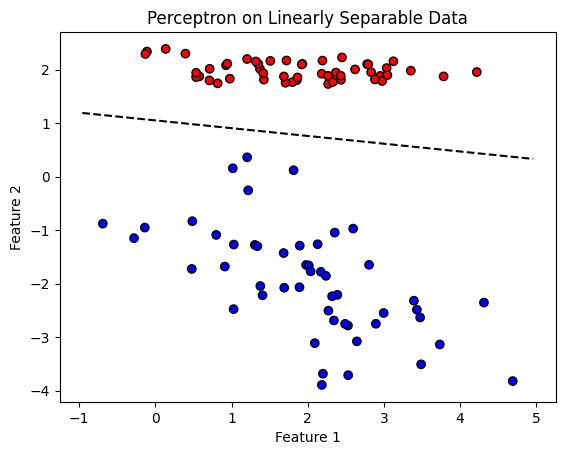

In [2]:
X, y = make_classification(n_samples=100, n_features=2, n_redundant=0, n_informative=2,
                           n_clusters_per_class=1, class_sep=2.0, random_state=0)
y = 2 * y - 1  # convert labels from {0,1} to {-1,1}

model = Perceptron(max_iter=1000)
model.fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create decision boundary
xx = np.linspace(xlim[0], xlim[1])
w = model.coef_[0]
b = model.intercept_[0]
yy = -(w[0] * xx + b) / w[1]

plt.plot(xx, yy, 'k--')
plt.title("Perceptron on Linearly Separable Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

✅ **Strength**: The Perceptron algorithm converges quickly on linearly separable data and finds a correct decision boundary.

## 3. Non-Linearly Separable Data

Now let’s try the Perceptron on data that is **not** linearly separable. The Perceptron will attempt to find a linear boundary, but it won’t be able to classify all points correctly.


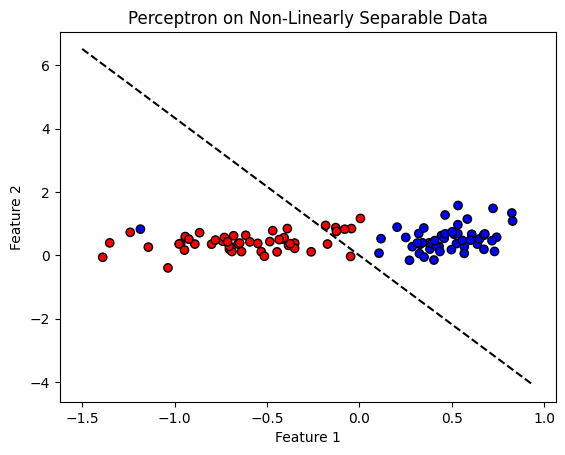

In [3]:
X_nl, y_nl = make_classification(n_samples=100, n_features=2, n_redundant=0,
                                 n_informative=2, n_clusters_per_class=1,
                                 class_sep=0.5, flip_y=0.1, random_state=1)
y_nl = 2 * y_nl - 1

model_nl = Perceptron(max_iter=1000)
model_nl.fit(X_nl, y_nl)

plt.scatter(X_nl[:, 0], X_nl[:, 1], c=y_nl, cmap='bwr', edgecolors='k')
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1])
w = model_nl.coef_[0]
b = model_nl.intercept_[0]
yy = -(w[0] * xx + b) / w[1]

plt.plot(xx, yy, 'k--')
plt.title("Perceptron on Non-Linearly Separable Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


⚠️ **Weakness**: The Perceptron does not converge on non-linearly separable data and may misclassify points indefinitely.


## 4. Quantitative Performance Check

To further evaluate the Perceptron’s performance, let’s measure its classification accuracy on a test set. This gives us a numeric indicator of how well the model performs when it cannot find a perfect separation boundary.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X_nl, y_nl, test_size=0.2, random_state=42)

model_eval = Perceptron(max_iter=1000)
model_eval.fit(X_train, y_train)

y_pred = model_eval.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))


Test Accuracy: 0.95


## 5. Summary and Reflection

In this notebook, you explored the Perceptron algorithm and observed how it behaves under different types of data. When applied to linearly separable data, the Perceptron was able to find an appropriate decision boundary after a series of weight updates. This demonstrates the algorithm’s strength in simple, well-structured scenarios — it is fast, intuitive, and guaranteed to converge if a perfect linear separation exists.

However, when the data was not linearly separable, the Perceptron struggled. Without a clear boundary to learn, the algorithm continued to adjust weights without finding a satisfactory solution. This limitation is critical to understand, as many real-world problems involve overlapping classes, noise, or more complex decision boundaries.

The Perceptron is a foundational algorithm that introduces key ideas like linear decision boundaries and iterative learning. But due to its simplicity, it is not suitable for all types of classification tasks — especially those that require flexibility or non-linear modeling.

Try to answer the following question for yourself:

When would you **not** want to use the Perceptron?

A. When data is perfectly linearly separable  
B. When you need a fast and online-updatable classifier  
C. When your data includes noise and overlapping classes  
D. When you need a simple baseline model

Select your answer and explain why.